# 01 - Exploratory Data Analysis
### CyberThreat-ML: AI-Powered Cyber Threat Intelligence and Intrusion Detection System

This notebook loads the raw CICIDS2017 flow CSVs, merges and cleans them using the
project's shared `src/preprocessing.py`, and explores the resulting dataset before
the classification, regression, and clustering notebooks build on it.

**Note on this notebook's status:** every cell below contains real, working code
using the project's actual `src/` modules. It has not yet been executed against
the real dataset in this environment -- run it top to bottom (or via
`jupyter nbconvert --execute`) once `data/raw/` contains the real CICIDS2017 CSVs.


## 1. Imports and setup

In [2]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join("..", "src"))
import preprocessing as prep
import utils

utils.set_plot_style()
RAW_DIR = os.path.join("..", "data", "raw")
PROCESSED_DIR = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)


## 2. Load and merge the raw CICIDS2017 CSV files

We use `load_and_merge_csvs()` from `src/preprocessing.py` instead of writing
loading logic here, so every notebook in this project merges the data the exact
same way -- one definition, reused everywhere.

In [3]:
df, load_report = prep.load_and_merge_csvs(RAW_DIR)

print(f"Files merged: {load_report['_FILES_MERGED_']}")
for fname, count in load_report.items():
    if not fname.startswith("_"):
        print(f"  {fname}: {count:,} rows")
print(f"\nTotal rows before cleaning: {load_report['_TOTAL_']:,}")


Files merged: 8
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows
  Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows

Total rows before cleaning: 2,830,743


## 3. Standardize column names

CICIDS2017's day-files are notorious for inconsistent column names across files
(leading/trailing spaces, mixed case, stray punctuation like the `/` in
`Flow Bytes/s`). `standardize_columns()` fixes this once, here, so every other
notebook can rely on stable `lower_snake_case` names regardless of which
day-file a column originally came from.

In [4]:
df = prep.standardize_columns(df)
print(f"Columns ({len(df.columns)}):")
print(list(df.columns))


Columns (79):
['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'fwd_packet_length_std', 'bwd_packet_length_max', 'bwd_packet_length_min', 'bwd_packet_length_mean', 'bwd_packet_length_std', 'flow_bytess', 'flow_packetss', 'flow_iat_mean', 'flow_iat_std', 'flow_iat_max', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_mean', 'fwd_iat_std', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_mean', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_psh_flags', 'bwd_psh_flags', 'fwd_urg_flags', 'bwd_urg_flags', 'fwd_header_length', 'bwd_header_length', 'fwd_packetss', 'bwd_packetss', 'min_packet_length', 'max_packet_length', 'packet_length_mean', 'packet_length_std', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'rst_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'cwe_flag_count', 'ece_

## 4. Dataset shape and column information

In [5]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.info()


Shape: 2,830,743 rows x 79 columns
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   destination_port             int64  
 1   flow_duration                int64  
 2   total_fwd_packets            int64  
 3   total_backward_packets       int64  
 4   total_length_of_fwd_packets  int64  
 5   total_length_of_bwd_packets  int64  
 6   fwd_packet_length_max        int64  
 7   fwd_packet_length_min        int64  
 8   fwd_packet_length_mean       float64
 9   fwd_packet_length_std        float64
 10  bwd_packet_length_max        int64  
 11  bwd_packet_length_min        int64  
 12  bwd_packet_length_mean       float64
 13  bwd_packet_length_std        float64
 14  flow_bytess                  float64
 15  flow_packetss                float64
 16  flow_iat_mean                float64
 17  flow_iat_std                 float64
 18  flow_iat_max      

In [6]:
df.describe().T


/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/nuraxx__/Documents/ML_PROJECT/venv/lib64/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
destination_port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
flow_duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
total_fwd_packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
total_backward_packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
total_length_of_fwd_packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
active_min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
idle_mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
idle_std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
idle_max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


## 5. Missing values, Infinity values, and duplicates

CICFlowMeter-derived datasets are known to contain a small but real number of
`Infinity` values (from division by zero in `flow_bytes_s` / `flow_packets_s`
when `flow_duration` is 0) and some NaNs and duplicate rows. `clean_data()`
handles all three and -- critically -- reports exactly how many rows were
affected by each issue, rather than silently dropping them.

In [7]:
df_clean, clean_report = prep.clean_data(df)


Rows before cleaning:        2,830,743
Rows with Infinity:          2,867
Rows with NaN:               2,867
Duplicate rows removed:      307,078
Identifier columns dropped:  []
Rows after cleaning:         2,520,798


## 6. Save the cleaned dataset

This is the file every other notebook (classification, regression, clustering)
loads from, so cleaning only happens in one place.

In [8]:
clean_path = os.path.join(PROCESSED_DIR, "cleaned_dataset.csv")
df_clean.to_csv(clean_path, index=False)
print(f"Saved: {clean_path}")
print(f"Final shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Saved: ../data/processed/cleaned_dataset.csv
Final shape: 2,520,798 rows x 79 columns


## 7. Label distribution and class imbalance

This is a multiclass problem (BENIGN plus several attack categories). CICIDS2017
is known to be heavily imbalanced -- the literature consistently reports over
70% of traffic as BENIGN, with some attack categories (Heartbleed especially)
represented by only a handful of rows. We check the real numbers here rather
than assume the literature's figures apply exactly to this cleaned version.

In [9]:
label_col = "label"
counts = df_clean[label_col].value_counts()
percentages = (counts / len(df_clean) * 100).round(2)

label_summary = pd.DataFrame({"count": counts, "percent": percentages})
label_summary


,count,percent
label,,
BENIGN,2095057,83.11
DoS Hulk,172846,6.86
DDoS,128014,5.08
PortScan,90694,3.60
DoS GoldenEye,10286,0.41
FTP-Patator,5931,0.24
DoS slowloris,5385,0.21
DoS Slowhttptest,5228,0.21
SSH-Patator,3219,0.13


## 8. Attack visualization

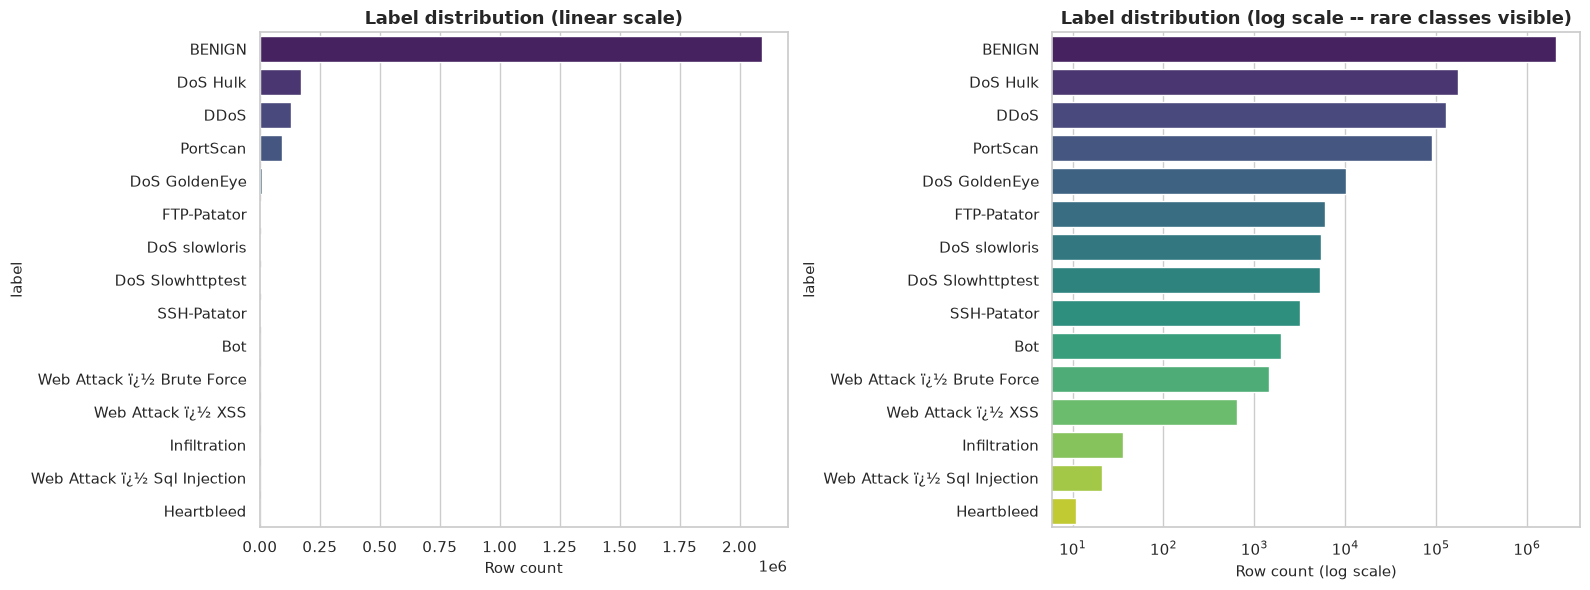

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=counts.values, y=counts.index, ax=axes[0], hue=counts.index, legend=False, palette="viridis")
axes[0].set_xlabel("Row count")
axes[0].set_title("Label distribution (linear scale)")

sns.barplot(x=counts.values, y=counts.index, ax=axes[1], hue=counts.index, legend=False, palette="viridis")
axes[1].set_xscale("log")
axes[1].set_xlabel("Row count (log scale)")
axes[1].set_title("Label distribution (log scale -- rare classes visible)")

plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "label_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


### Class imbalance analysis

The imbalance ratio (largest class / smallest class) tells us how aggressively
we'll need to handle this in the classification notebook (`class_weight`,
stratified sampling, and reporting macro-F1 alongside weighted F1 so rare-class
performance can't hide behind BENIGN's volume).

In [11]:
imbalance_ratio = counts.max() / counts.min()
print(f"Largest class:  {counts.idxmax()} ({counts.max():,} rows)")
print(f"Smallest class: {counts.idxmin()} ({counts.min():,} rows)")
print(f"Imbalance ratio: {imbalance_ratio:,.1f} : 1")


Largest class:  BENIGN (2,095,057 rows)
Smallest class: Heartbleed (11 rows)
Imbalance ratio: 190,459.7 : 1


## 9. Feature distributions

A look at the shape of a few key behavioral features -- these are also the raw
ingredients for the risk score built in `src/risk_score.py`.

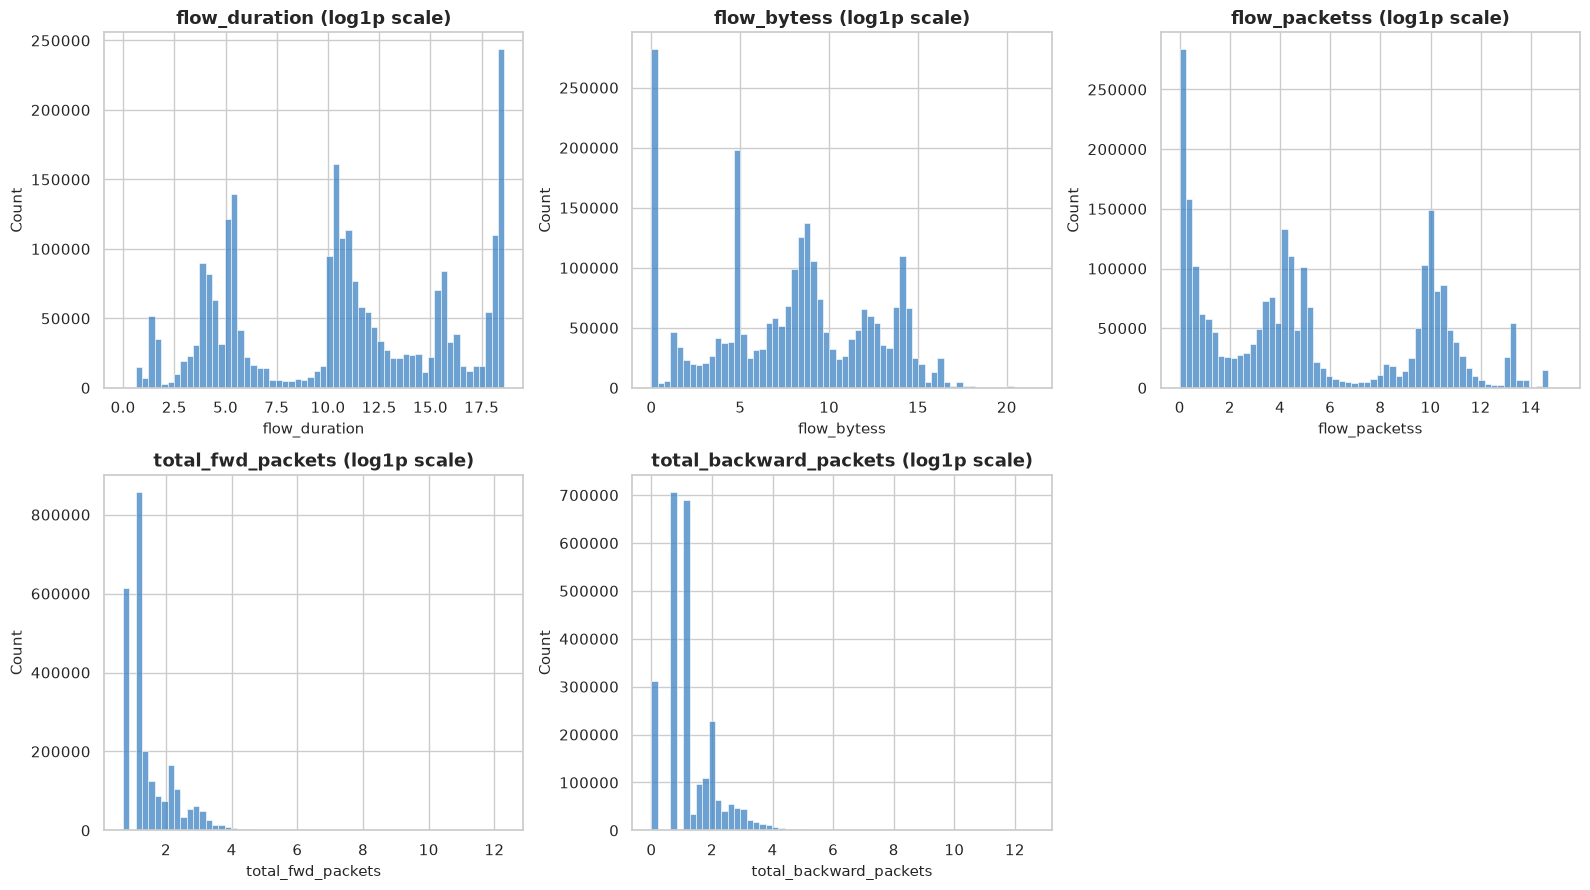

In [12]:
key_features = [c for c in ["flow_duration", "flow_bytess", "flow_packetss",
                            "total_fwd_packets", "total_backward_packets"]
                if c in df_clean.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    # log1p because these flow features are heavily right-skewed
    sns.histplot(np.log1p(df_clean[feat].clip(lower=0)), bins=60, ax=axes[i], color="#3B82C4")
    axes[i].set_title(f"{feat} (log1p scale)")
    axes[i].set_xlabel(feat)

for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


## 10. Correlation heatmap

With ~78 numerical features, some redundancy is expected (e.g. total packet
length vs. subflow bytes). This matters most for the clustering notebook,
where correlated features silently double-count in distance calculations --
the list of highly correlated pairs below feeds directly into that
notebook's correlation-pruning step.

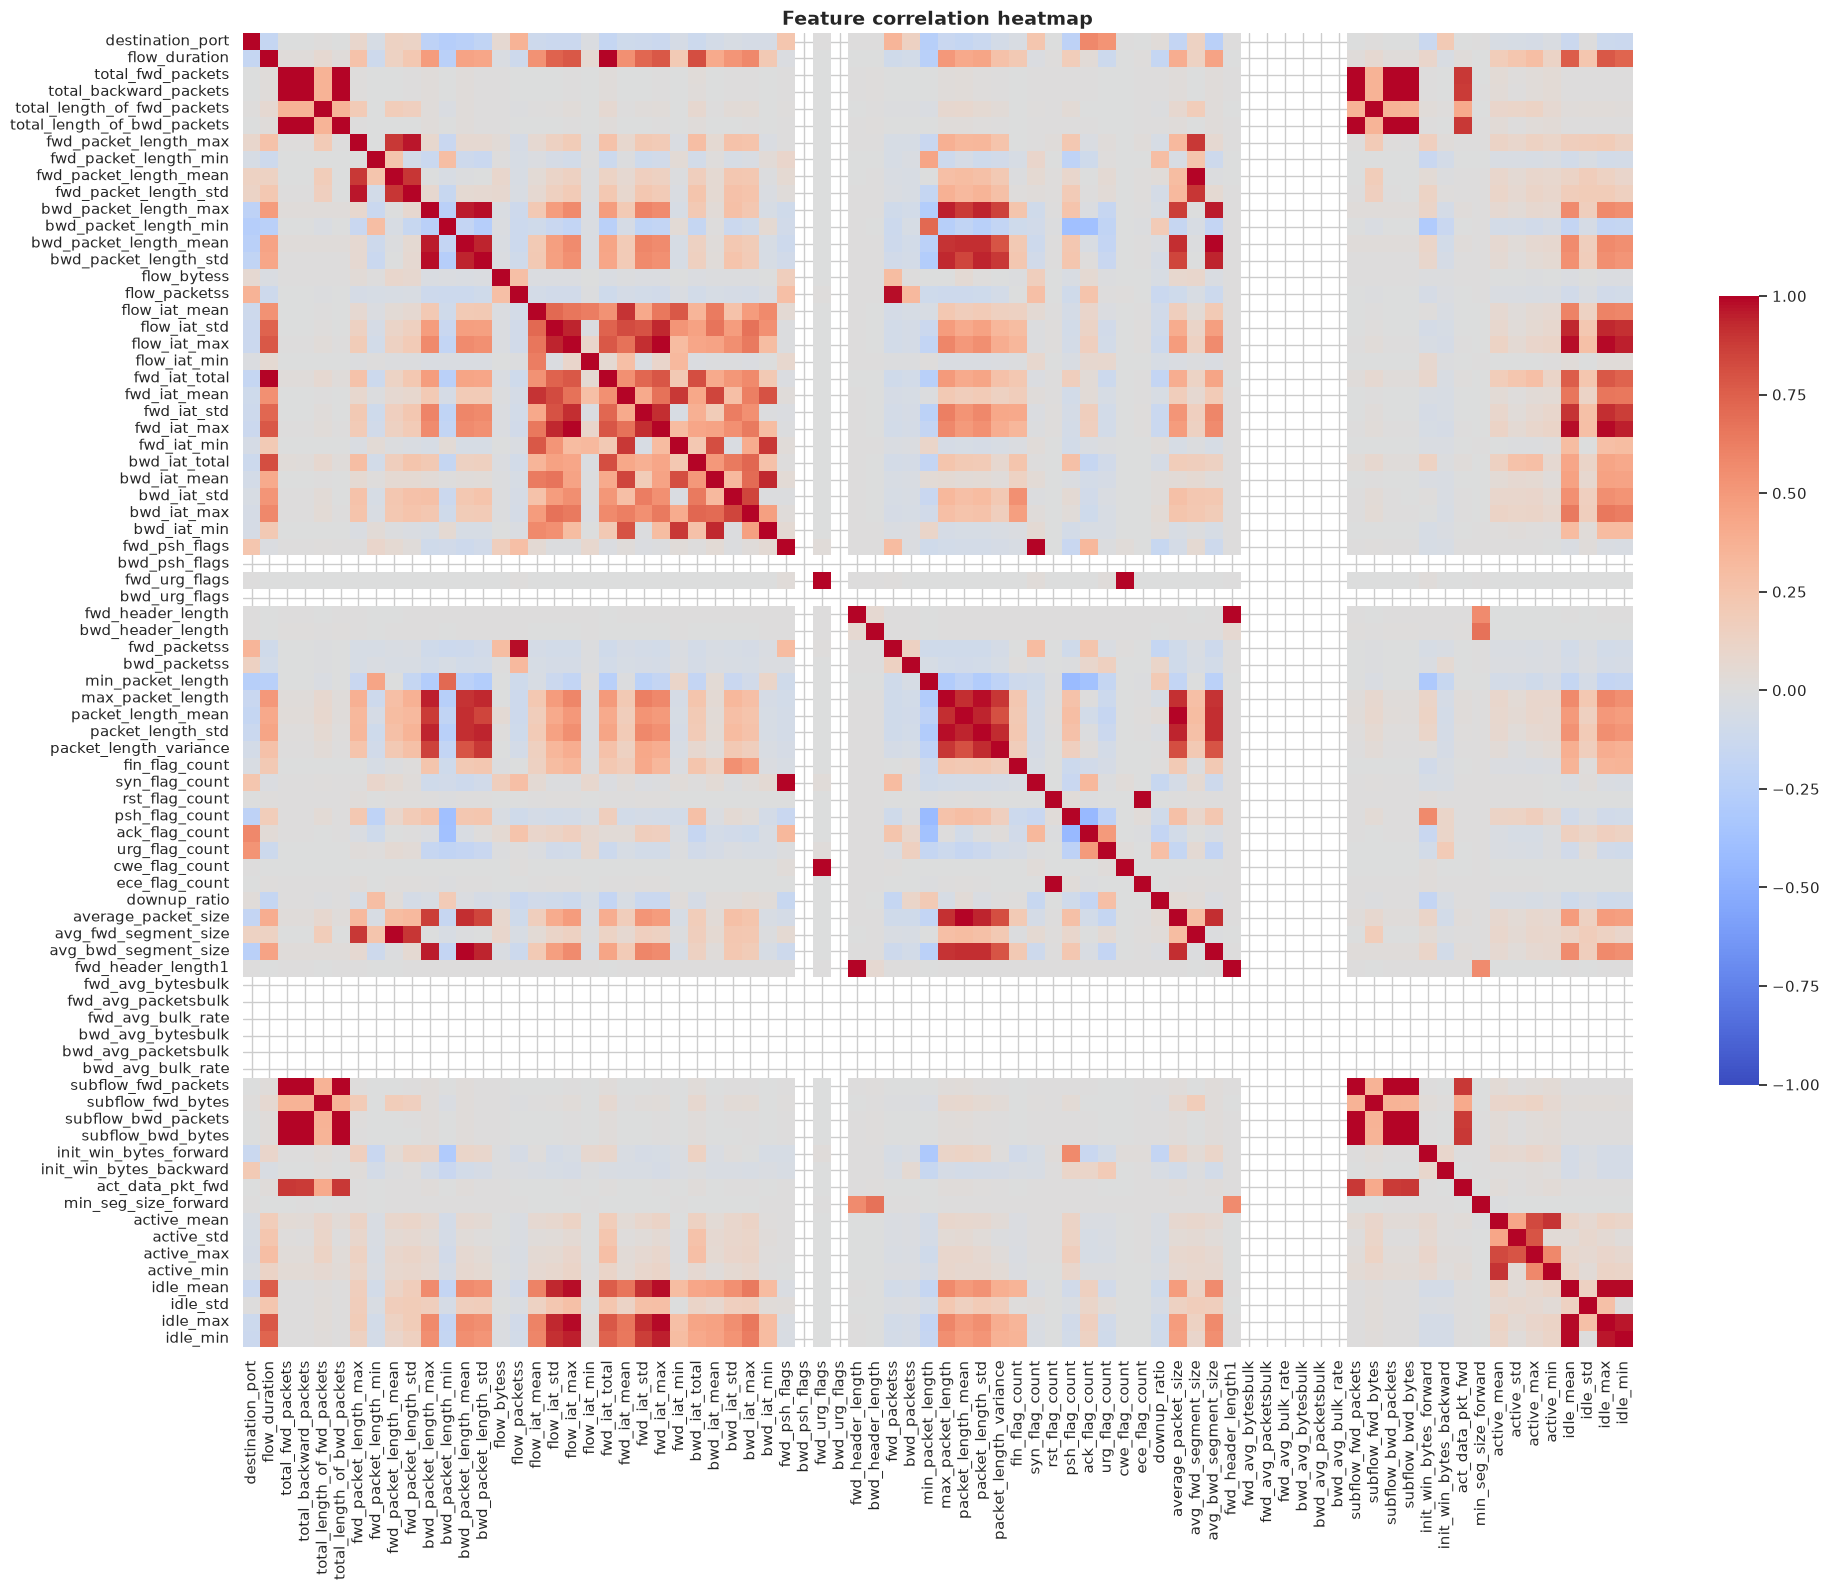

In [13]:
numeric_df = df_clean.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "figures", "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# Actionable follow-up: which specific pairs are highly correlated?
threshold = 0.9
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) >= threshold:
            pairs.append((corr.columns[i], corr.columns[j], round(r, 3)))

high_corr = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr = high_corr.sort_values("correlation", key=abs, ascending=False)
print(f"{len(high_corr)} feature pairs with |correlation| >= {threshold}")
high_corr.head(20)


71 feature pairs with |correlation| >= 0.9


,feature_1,feature_2,correlation
3,total_fwd_packets,subflow_fwd_packets,1.000
50,fwd_urg_flags,cwe_flag_count,1.000
26,bwd_packet_length_mean,avg_bwd_segment_size,1.000
15,fwd_packet_length_mean,avg_fwd_segment_size,1.000
13,total_length_of_bwd_packets,subflow_bwd_bytes,1.000
10,total_length_of_fwd_packets,subflow_fwd_bytes,1.000
8,total_backward_packets,subflow_bwd_packets,1.000
51,fwd_header_length,fwd_header_length1,1.000
49,fwd_psh_flags,syn_flag_count,1.000
64,subflow_fwd_packets,subflow_bwd_packets,0.999


## 11. Important observations

*(This cell is a template -- replace each bullet with what you actually observe
once this notebook is run against the real dataset. Do not submit this
section unedited.)*

- **Dataset size:** `<fill in df_clean.shape once run>`
- **Class imbalance:** `<fill in the imbalance ratio and which classes are
  critically rare -- this determines whether class_weight='balanced' or
  SMOTE is needed in the classification notebook>`
- **Cleaning impact:** `<how many rows had Infinity/NaN, how many duplicates
  -- if this is a large fraction of the data, investigate why before moving on>`
- **Correlated features:** `<how many pairs exceeded the 0.9 threshold, and
  whether any are between features that sound conceptually identical -- these
  are candidates to drop before clustering>`
- **Feature distributions:** `<which features are extremely skewed --
  relevant to whether scaling alone is enough or a transform is needed>`
- **Destination port:** worth a quick separate check -- does `destination_port`
  correlate strongly with specific attack labels? If so, flag it for the
  port-leakage ablation study in the classification notebook rather than
  silently relying on it.
